# Decision Tree Overfitting
In this notebook, we:

- Learned what overfitting is.
- Generated a non-linear classification dataset.
- Trained Decision Trees with different depths.
- Compared training and testing accuracy.
- Visualized how tree depth affects model performance.
- Identified the depth that provides the best generalization.

This notebook demonstrates how increasing tree complexity can improve training performance while potentially hurting performance on unseen data.

## Overfitting

Overfitting occurs when a machine learning model learns the training data too well, including noise and random fluctuations, instead of learning the true underlying patterns.

As a result:

- Training accuracy becomes very high.
- Testing accuracy becomes lower.
- The model performs poorly on new unseen data.

```text
Training Data: ✓ Correctly memorized
New Data: ✗ Makes more mistakes
````

A highly complex Decision Tree can create many splits that perfectly fit the training set but fail to generalize.

## Imports

| Library                          | Purpose                                       |
| -------------------------------- | --------------------------------------------- |
| NumPy (`numpy`)                  | Numerical computations                        |
| Matplotlib (`matplotlib.pyplot`) | Data visualization                            |
| `DecisionTreeClassifier`         | Builds Decision Tree models                   |
| `make_moons`                     | Generates a non-linear classification dataset |
| `train_test_split`               | Splits data into training and testing sets    |
| `accuracy_score`                 | Evaluates model accuracy                      |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## Generate Dataset (make_moons())
The `make_moons()` dataset creates two interleaving crescent-shaped classes. This dataset is useful for studying Decision Trees because it contains non-linear patterns.

| Variable | Description    |
| -------- | -------------- |
| `X`      | Feature matrix |
| `y`      | Target labels  |

In [2]:
X, y = make_moons(
    n_samples=500,         # Total observations
    noise=0.25,            # Adds randomness to make classification harder
    random_state=42        # Produces reproducible results
)

In [3]:
X

array([[ 8.30948469e-01, -2.96545518e-01],
       [ 1.08838668e+00,  8.99693401e-01],
       [ 1.13563371e+00, -4.62934669e-01],
       [-8.22773904e-02,  1.05971844e+00],
       [ 4.43047449e-01,  1.41897660e+00],
       [ 1.30029990e+00, -5.37627947e-01],
       [ 1.14310920e+00, -2.15442010e-01],
       [ 1.31665066e-01,  1.26513975e+00],
       [ 4.86749763e-01,  5.39479136e-01],
       [ 1.67864907e+00, -3.96435236e-01],
       [ 1.02113484e+00,  5.80133114e-03],
       [-4.61188138e-01,  3.16754158e-01],
       [ 1.77578097e+00, -6.67358687e-01],
       [ 1.79476279e-01,  6.66101895e-01],
       [ 1.44367544e+00, -5.09046437e-01],
       [ 1.30186381e+00, -5.31502273e-01],
       [ 1.97620714e+00,  3.23084055e-01],
       [ 9.41904062e-01,  4.93181804e-01],
       [ 7.46703853e-01, -7.08375670e-01],
       [ 1.81289662e+00, -2.80009291e-01],
       [ 1.90161925e+00,  2.49761452e-01],
       [ 2.25582933e+00,  4.56481228e-01],
       [-3.12734352e-01,  2.21235570e-01],
       [ 1.

In [4]:
y

array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,

## Train-Test Split

Machine learning models should be evaluated on data they have never seen before.

The dataset is divided into:

| Dataset      | Purpose              |
| ------------ | -------------------- |
| Training Set | Learn patterns       |
| Testing Set  | Evaluate performance |

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,   # 30% testing data
    random_state=42  # Reproducible split
)

## Tree Depths

Tree depth controls model complexity.

```text
Depth = Number of levels in the tree
```

|Purpose|Small Depth|Large Depth|
|-------|-----------|-----------|
|  Model| Simple    | Complex   |
|   Bias| High      |  Low      |
| Fitting|Underfitting|Overfitting
|Training accuracy|Low|High|
|Testing accuracy| Low| Decreasing |
|Memorize|Model Learn cannot learn enough patterns|Model memorizes training data|

Larger depth allows more complex decision boundaries.

In [6]:
depths = list(range(1, 15))
depths

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

## Training Accuracy

Usually increases as depth increases.

## Testing Accuracy

* Increases initially.
* Reaches a peak.
* Starts decreasing when overfitting occurs.

The gap between training and testing accuracy is a strong indicator of overfitting.

## Accuracy Scores
Accuracy measures how many predictions are correct.

`Accuracy =  Correct Predictions / Total Predictions`
 Accuracy | Meaning                            |
| -------- | ---------------------------------- |
| 1.00     | Perfect predictions                |
| 0.90     | 90% correct                        |
| 0.50     | Random guessing for binary classes |

Higher accuracy generally indicates better performance.    

A typical graph looks like:

```text
Accuracy

1.0 |                    *
    |                   *
0.9 |                 *
    |               *
0.8 |           * *
    |         *
0.7 |      *
    |
    +---------------------------->
       Small     Medium     Large
              Tree Depth

In [7]:
train_acc = []  # Training accuracy values
test_acc = []   # Testing accuracy values

for d in depths:
    # Create a Decision Tree
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )
    # Train the model.
    model.fit(X_train, y_train)
    # Predict training samples.
    train_pred = model.predict(X_train)
    # Predict testing samples.
    test_pred = model.predict(X_test)
    # Calculate training accuracy.
    train_acc.append(
        accuracy_score(y_train, train_pred)
    )
    # Calculate testing accuracy.
    test_acc.append(
        accuracy_score(y_test, test_pred)
    )

## Visualization

The graph compares training and testing accuracy for different tree depths.

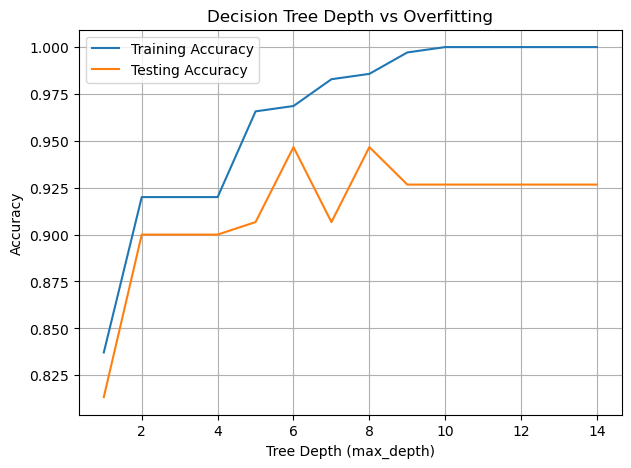

In [10]:
plt.figure(figsize=(7,5))
plt.plot(depths, train_acc, label="Training Accuracy")
plt.plot(depths, test_acc, label="Testing Accuracy")
plt.title("Decision Tree Depth vs Overfitting")
plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.savefig("Decision Tree Depth VS Overfitting.png", dpi=100)
plt.show()

### Ideal Depth
The ideal depth is the one that achieves the highest testing accuracy.

| Function           | Purpose                              |
| ------------------ | ------------------------------------ |
| `np.argmax()`      | Returns index of maximum value       |
| `train_best_depth` | Depth with highest training accuracy |
| `test_best_depth`  | Depth with highest testing accuracy  |    

In [9]:
train_best_depth = depths[np.argmax(train_acc)]
test_best_depth = depths[np.argmax(test_acc)]

## Key Takeaways

* Decision Trees become more complex as depth increases.
* Small depth may underfit the data.
* Large depth may overfit the data.
* Training accuracy usually increases with depth.
* Testing accuracy helps identify the best model.
* The best depth is typically where testing accuracy is highest.
* Monitoring both training and testing accuracy helps detect overfitting.

This notebook provides the foundation for understanding how Decision Tree complexity affects model performance before learning pruning techniques and advanced regularization methods.